In [10]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [16]:
from torch.utils.data import DataLoader
import torch
from src.dataset import OilSpillDataset


train_dataset = OilSpillDataset(
    image_dir="../data/images/train",
    mask_dir="../data/masks/train",
)

val_dataset = OilSpillDataset(
    image_dir="../data/images/val",
    mask_dir="../data/masks/val",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print("train:", len(train_dataset))
print("val:", len(val_dataset))

train: 6455
val: 1615


In [17]:
images, masks = next(iter(train_loader))

print("images:", images.shape)
print("masks:", masks.shape)

print("image dtype:", images.dtype)
print("mask dtype:", masks.dtype)

print("image min:", images.min().item())
print("image max:", images.max().item())

print("mask values:", torch.unique(masks))

images: torch.Size([16, 1, 256, 256])
masks: torch.Size([16, 1, 256, 256])
image dtype: torch.float32
mask dtype: torch.float32
image min: 0.0
image max: 1.0
mask values: tensor([0., 1.])


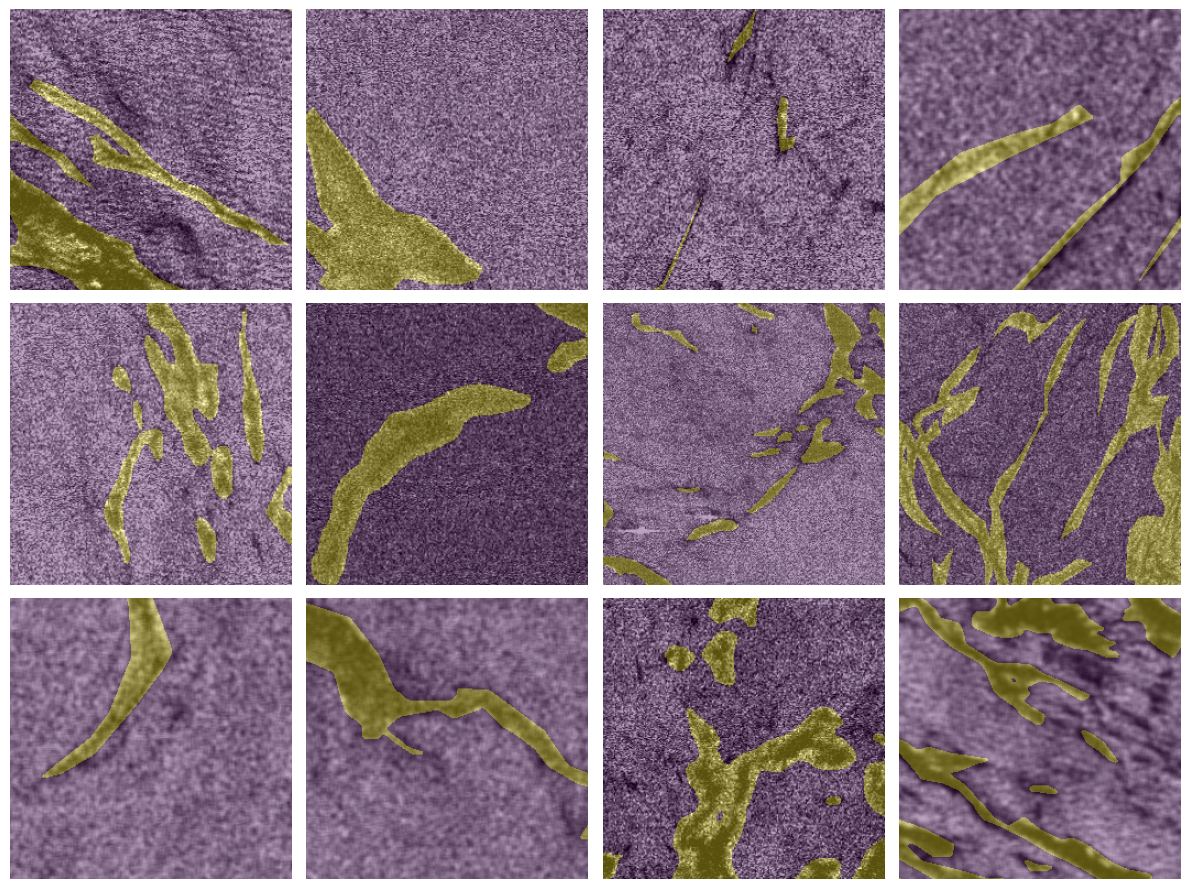

In [20]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flat):
    image = images[i].squeeze().numpy()
    mask = masks[i].squeeze().numpy()

    ax.imshow(image, cmap="gray")
    ax.imshow(mask, alpha=0.35)
    ax.axis("off")

plt.tight_layout()
plt.show()